# Economics Interactive Lab -- modules from scratch

This notebook calls several of this project's `EconModule.compute(...)` functions
directly, with no Streamlit UI involved, to show the underlying math on its own.
Every number below is an illustrative input chosen for this walkthrough, not an
estimate of any real market, economy, or financial product -- see
`docs/METHODOLOGY.md` for the full equations and assumptions behind each module.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np

from econ_lab.modules import (
    micro_supply_demand,
    micro_elasticity,
    micro_tax_incidence,
    macro_multiplier,
    macro_growth,
    finance_compound_interest,
    finance_diversification,
)


## 1. Demand & supply equilibrium

P* = 25.714, Q* = 48.571


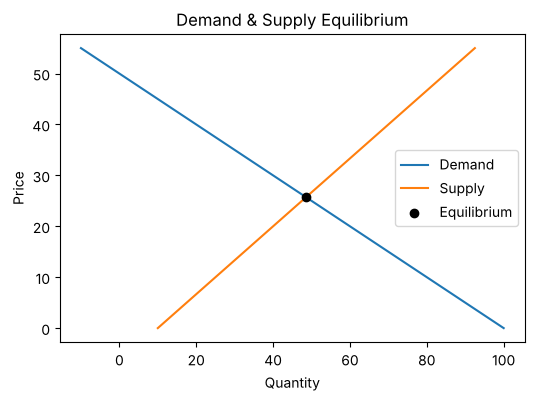

In [2]:
a, b, c, d = 100.0, 2.0, 10.0, 1.5
eq = micro_supply_demand.compute(a=a, b=b, c=c, d=d)
print(f"P* = {eq['p_star']:.3f}, Q* = {eq['q_star']:.3f}")

prices = np.linspace(0, eq["demand_price_intercept"] * 1.1, 200)
demand_q = a - b * prices
supply_q = c + d * prices

plt.figure(figsize=(6, 4))
plt.plot(demand_q, prices, label="Demand")
plt.plot(supply_q, prices, label="Supply")
plt.scatter([eq["q_star"]], [eq["p_star"]], color="black", zorder=5, label="Equilibrium")
plt.xlabel("Quantity"); plt.ylabel("Price"); plt.legend(); plt.title("Demand & Supply Equilibrium")
plt.show()


## 2. Price elasticity of demand along the same curve

In [3]:
sample_prices = np.linspace(1, a / b - 1, 8)
for p in sample_prices:
    result = micro_elasticity.compute(a=a, b=b, price=p)
    print(f"P={p:6.2f}  Q={result['quantity']:6.2f}  PED={result['elasticity']:7.3f}  ({result['label']})")


P=  1.00  Q= 98.00  PED= -0.020  (inelastic)
P=  7.86  Q= 84.29  PED= -0.186  (inelastic)
P= 14.71  Q= 70.57  PED= -0.417  (inelastic)
P= 21.57  Q= 56.86  PED= -0.759  (inelastic)
P= 28.43  Q= 43.14  PED= -1.318  (elastic)
P= 35.29  Q= 29.43  PED= -2.398  (elastic)
P= 42.14  Q= 15.71  PED= -5.364  (elastic)
P= 49.00  Q=  2.00  PED=-49.000  (elastic)


## 3. Tax incidence: burden split by relative elasticity

In [4]:
tax_result = micro_tax_incidence.compute(a=a, b=b, c=c, d=d, tax=10.0)
print(f"Consumer price: {tax_result['p_consumer']:.2f}   Producer price: {tax_result['p_producer']:.2f}")
print(f"Consumer share of burden: {tax_result['consumer_burden_share']*100:.1f}%")
print(f"Producer share of burden: {tax_result['producer_burden_share']*100:.1f}%")
print(f"Deadweight loss: {tax_result['deadweight_loss']:.2f}")


Consumer price: 30.00   Producer price: 20.00
Consumer share of burden: 42.9%
Producer share of burden: 57.1%
Deadweight loss: 42.86


## 4. Fiscal multiplier: the spending-round geometric series

Multiplier = 4.00x,  total delta_Y = 200.00


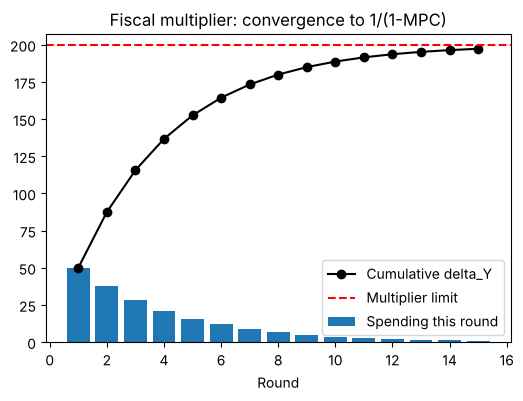

In [5]:
mult = macro_multiplier.compute(mpc=0.75, delta_g=50.0, rounds=15)
print(f"Multiplier = {mult['multiplier']:.2f}x,  total delta_Y = {mult['delta_y']:.2f}")

plt.figure(figsize=(6, 4))
rounds = range(1, len(mult["round_spending"]) + 1)
plt.bar(rounds, mult["round_spending"], label="Spending this round")
plt.plot(rounds, mult["cumulative"], color="black", marker="o", label="Cumulative delta_Y")
plt.axhline(mult["delta_y"], color="red", linestyle="--", label="Multiplier limit")
plt.xlabel("Round"); plt.legend(); plt.title("Fiscal multiplier: convergence to 1/(1-MPC)")
plt.show()


## 5. Solow-style growth: convergence to the same steady state from different starting points

Steady-state k* = 5.154 (same for both runs)


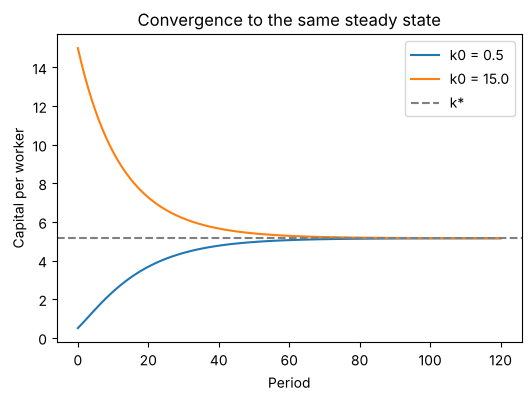

In [6]:
s, delta, alpha = 0.3, 0.1, 0.33
low = macro_growth.compute(s=s, delta=delta, alpha=alpha, k0=0.5, periods=120)
high = macro_growth.compute(s=s, delta=delta, alpha=alpha, k0=15.0, periods=120)
print(f"Steady-state k* = {low['k_star']:.3f} (same for both runs)")

plt.figure(figsize=(6, 4))
plt.plot(low["capital_path"], label="k0 = 0.5")
plt.plot(high["capital_path"], label="k0 = 15.0")
plt.axhline(low["k_star"], color="gray", linestyle="--", label="k*")
plt.xlabel("Period"); plt.ylabel("Capital per worker"); plt.legend()
plt.title("Convergence to the same steady state")
plt.show()


## 6. Compound interest vs. present value

In [7]:
ci = finance_compound_interest.compute(principal=10000.0, rate=0.07, periods=20, contribution=1000.0)
print(f"Future value (lump sum):     {ci['fv_lump']:,.2f}")
print(f"Future value (contributions): {ci['fv_annuity']:,.2f}")
print(f"Total future value:          {ci['fv_total']:,.2f}")
print(f"Present value of that total: {ci['present_value']:,.2f}")


Future value (lump sum):     38,696.84
Future value (contributions): 40,995.49
Total future value:          79,692.34
Present value of that total: 20,594.01


## 7. Two-asset diversification: risk falls as correlation falls

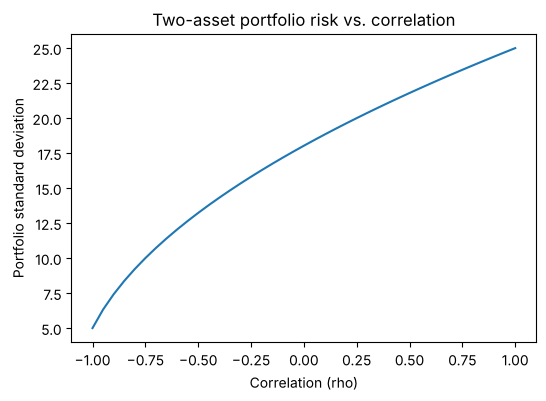

In [8]:
rhos = np.linspace(-1, 1, 41)
stds = [finance_diversification.compute(w1=0.5, sigma1=20.0, sigma2=30.0, rho=r)["portfolio_std"] for r in rhos]

plt.figure(figsize=(6, 4))
plt.plot(rhos, stds)
plt.xlabel("Correlation (rho)"); plt.ylabel("Portfolio standard deviation")
plt.title("Two-asset portfolio risk vs. correlation")
plt.show()
